# UNIX AI Job Assistant: Resume and Job Matching

This beginner notebook explores a small resume dataset, predicts one of three job categories, and finds job descriptions that look similar to a resume. It is a prototype for the UNIX student app's AI Job Assistant.

**Small-data warning:** this file has only 32 resumes. A few examples can strongly change the scores, so the results are for learning and prototyping. They are not proof that a model will work well for real students.

## Step 2 — Install and import libraries

The next cell imports the tools used in this notebook. If a library is missing in a new environment, install the listed packages first.

In [ ]:
# Install if needed in a fresh notebook environment:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud joblib

# Import tools for data, charts, text processing, models, and saved files.
import re
import string
import warnings
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from wordcloud import WordCloud

# Keep notebook warnings readable.
warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
print("Libraries imported. Random state:", RANDOM_STATE)


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Libraries imported. Random state: 42


## Step 3 — Load the data

The CSV is stored next to this notebook. We inspect its size, columns, first rows, data types, and missing values before using it.

In [ ]:
# Read the dataset from the notebook folder.
data_path = Path("resume_dataset.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
df.info()
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count"))

Shape: (32, 2)
Columns: ['Category', 'Resume']


,Category,Resume
0,DESIGNER,floral designer summary personable customer se...
1,DESIGNER,lighting designer professional summary compute...
2,DESIGNER,product designer professional summary 4 5 year...
3,DESIGNER,mechanical designer summary im offering over t...
4,DESIGNER,technical designer summary special qualificati...


<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  32 non-null     str  
 1   Resume    32 non-null     str  
dtypes: str(2)
memory usage: 204.3 KB

Missing values per column:


,missing_count
Category,0
Resume,0


## Step 4 — Explore the data (EDA)

These charts show how many examples each category has, how long resumes are, and which words appear often. They help us understand the data before training.

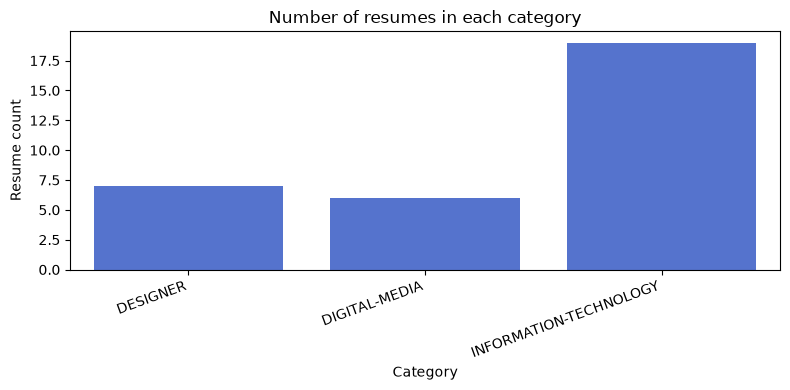

Comment: The categories do not have equal numbers of resumes, so a model may favor the larger category.


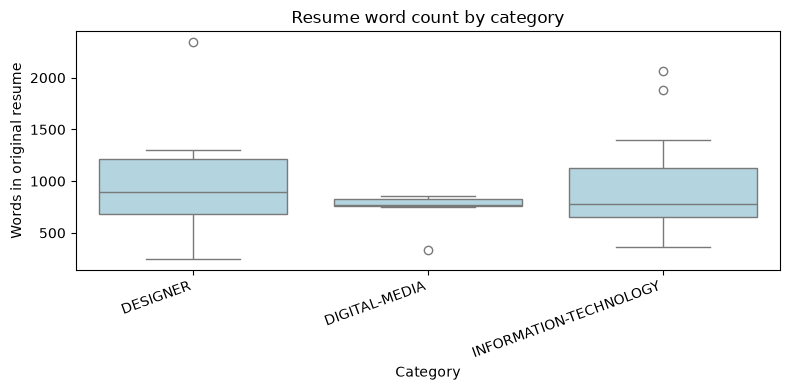

Comment: Longer resumes are not automatically better; the plot only compares document lengths.
Mean resume word count by category:


,mean_words
Category,
DESIGNER,1039.3
DIGITAL-MEDIA,722.2
INFORMATION-TECHNOLOGY,940.7



Top words for DESIGNER:


,word,count
0,and,443
1,to,187
2,of,159
3,the,149
4,for,130
5,design,113
6,in,81
7,with,78
8,state,68
9,city,63



Top words for DIGITAL-MEDIA:


,word,count
0,and,213
1,to,130
2,the,110
3,of,87
4,for,65
5,in,50
6,on,41
7,state,39
8,with,36
9,a,33



Top words for INFORMATION-TECHNOLOGY:


,word,count
0,and,1087
1,to,427
2,the,407
3,of,314
4,for,240
5,in,201
6,information,170
7,a,157
8,with,148
9,systems,144


Comment: Frequent words can reveal category themes, but common resume words may not distinguish jobs.


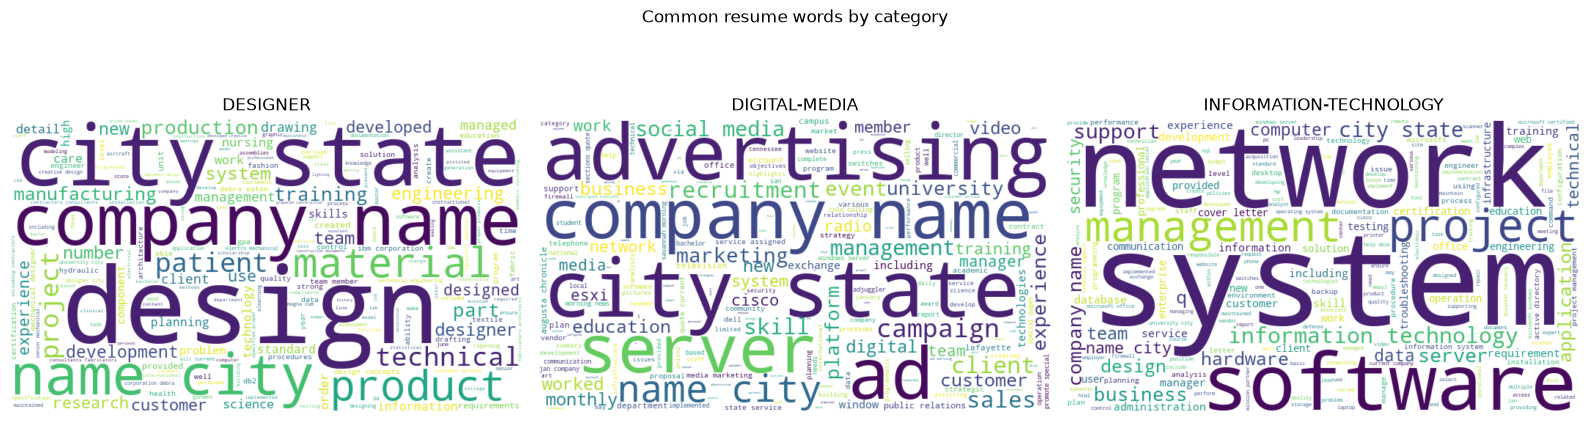

Comment: Larger words appear more often in that category's resumes.


In [ ]:
# Count words in the original resume text for a simple length comparison.
df["Word_Count_Before"] = df["Resume"].fillna("").astype(str).str.split().str.len()
category_counts = df["Category"].value_counts().sort_index()

# Bar chart: show the class imbalance clearly.
plt.figure(figsize=(8, 4))
sns.barplot(x=category_counts.index, y=category_counts.values, color="royalblue")
plt.title("Number of resumes in each category")
plt.xlabel("Category")
plt.ylabel("Resume count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
print("Comment: The categories do not have equal numbers of resumes, so a model may favor the larger category.")

# Box plot: compare resume lengths and show their spread.
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Category", y="Word_Count_Before", color="lightblue")
plt.title("Resume word count by category")
plt.xlabel("Category")
plt.ylabel("Words in original resume")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
print("Comment: Longer resumes are not automatically better; the plot only compares document lengths.")

# Print mean original word count per category.
mean_lengths = df.groupby("Category")["Word_Count_Before"].mean().round(1)
print("Mean resume word count by category:")
display(mean_lengths.to_frame("mean_words"))

# Show the 15 most common alphabetic words for each category.
for category in sorted(df["Category"].unique()):
    words = re.findall(r"[a-z]+", " ".join(df.loc[df["Category"] == category, "Resume"].fillna("").astype(str)).lower())
    common = Counter(words).most_common(15)
    print(f"\nTop words for {category}:")
    display(pd.DataFrame(common, columns=["word", "count"]))
print("Comment: Frequent words can reveal category themes, but common resume words may not distinguish jobs.")

# Make one word cloud per category. Fixed random_state keeps layouts repeatable.
fig, axes = plt.subplots(1, len(category_counts), figsize=(16, 5))
for ax, category in zip(np.atleast_1d(axes), sorted(df["Category"].unique())):
    text = " ".join(df.loc[df["Category"] == category, "Resume"].fillna("").astype(str))
    cloud = WordCloud(width=700, height=400, background_color="white", random_state=RANDOM_STATE).generate(text)
    ax.imshow(cloud, interpolation="bilinear")
    ax.set_title(category)
    ax.axis("off")
plt.suptitle("Common resume words by category")
plt.tight_layout()
plt.show()
print("Comment: Larger words appear more often in that category's resumes.")

## Step 5 — Clean the resume text

We lowercase text, remove punctuation, numbers, and special characters, remove NLTK stop words, and lemmatize words. The cleaned text is stored in `Clean_Resume`. NLTK downloads two small language resources if they are not already present.

In [ ]:
# Download resources used for English stop words and lemmatization.
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
english_stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    # Make text lowercase, remove digits/punctuation, then normalize its words.
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [lemmatizer.lemmatize(word) for word in text.split()
              if word not in english_stop_words and len(word) > 1]
    return " ".join(tokens)

df["Clean_Resume"] = df["Resume"].fillna("").apply(clean_resume)
df["Word_Count_After"] = df["Clean_Resume"].str.split().str.len()
print("Mean word count before cleaning:", round(df["Word_Count_Before"].mean(), 1))
print("Mean word count after cleaning:", round(df["Word_Count_After"].mean(), 1))
display(df[["Category", "Clean_Resume"]].head())

Mean word count before cleaning: 921.3
Mean word count after cleaning: 669.6


,Category,Clean_Resume
0,DESIGNER,floral designer summary personable customer se...
1,DESIGNER,lighting designer professional summary compute...
2,DESIGNER,product designer professional summary year eng...
3,DESIGNER,mechanical designer summary im offering twenty...
4,DESIGNER,technical designer summary special qualificati...


## Step 6 — Encode the category labels

Machine-learning models use numbers for labels. `LabelEncoder` maps each category to a number, and we keep the encoder so predictions can be changed back to names.

In [ ]:
# Convert category names to stable integer labels.
label_encoder = LabelEncoder()
df["Category_Encoded"] = label_encoder.fit_transform(df["Category"])
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label mapping: {'DESIGNER': np.int64(0), 'DIGITAL-MEDIA': np.int64(1), 'INFORMATION-TECHNOLOGY': np.int64(2)}


## Step 7 — Split training and test data

We keep 25% of resumes aside for a final check. Stratification keeps each category represented in both parts, which matters because the dataset is small and imbalanced.

In [ ]:
# Split raw cleaned text so TF-IDF can be fitted only on training data.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["Clean_Resume"], df["Category_Encoded"],
    test_size=0.25, random_state=RANDOM_STATE, stratify=df["Category_Encoded"]
)
print("Training examples:", len(X_train_text))
print("Test examples:", len(X_test_text))
print("Training labels:")
display(label_encoder.inverse_transform(y_train).tolist())
print("Test label counts:")
display(pd.Series(label_encoder.inverse_transform(y_test)).value_counts().sort_index())

Training examples: 24
Test examples: 8
Training labels:


['INFORMATION-TECHNOLOGY',
 'INFORMATION-TECHNOLOGY',
 'DIGITAL-MEDIA',
 'INFORMATION-TECHNOLOGY',
 'INFORMATION-TECHNOLOGY',
 'DIGITAL-MEDIA',
 'INFORMATION-TECHNOLOGY',
 'DESIGNER',
 'DESIGNER',
 'DESIGNER',
 'INFORMATION-TECHNOLOGY',
 'DIGITAL-MEDIA',
 'INFORMATION-TECHNOLOGY',
 'DIGITAL-MEDIA',
 'INFORMATION-TECHNOLOGY',
 'DESIGNER',
 'DESIGNER',
 'INFORMATION-TECHNOLOGY',
 'INFORMATION-TECHNOLOGY',
 'INFORMATION-TECHNOLOGY',
 'INFORMATION-TECHNOLOGY',
 'DIGITAL-MEDIA',
 'INFORMATION-TECHNOLOGY',
 'INFORMATION-TECHNOLOGY']

Test label counts:


DESIGNER                  2
DIGITAL-MEDIA             1
INFORMATION-TECHNOLOGY    5
Name: count, dtype: int64

## Step 8 — Turn text into TF-IDF features

TF-IDF gives more weight to useful words and less weight to words found everywhere. The vectorizer is fitted on training text only, then applied to test text so test information cannot leak into training.

In [ ]:
# Build one- and two-word features; fit only on training resumes.
tfidf_vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=1)
X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)
print("Training matrix:", X_train.shape)
print("Test matrix:", X_test.shape)
print("Number of TF-IDF features:", len(tfidf_vectorizer.get_feature_names_out()))

Training matrix: (24, 2000)
Test matrix: (8, 2000)
Number of TF-IDF features: 2000


## Step 9 — Train four models

We compare Logistic Regression, Multinomial Naive Bayes, Linear SVM, and Random Forest. The training split is used for fitting; the test split stays untouched until evaluation.

In [ ]:
# Set fixed seeds for models that use randomness.
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Multinomial Naive Bayes
Trained: Linear SVM


Trained: Random Forest


## Step 10 — Cross-validation

Four-fold stratified cross-validation reuses the training data in several train/validation splits while keeping category proportions. Each fold also fits its own TF-IDF vectorizer, avoiding leakage. With only 32 resumes, fold scores can still move a lot.

In [ ]:
# Use a pipeline so each fold learns its vocabulary from that fold's training data only.
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=1)),
        ("classifier", clone(model)),
    ])
    scores = cross_val_score(pipeline, X_train_text, y_train, cv=cv, scoring="accuracy", n_jobs=1)
    cv_rows.append({"Model": name, "CV mean accuracy": scores.mean(), "CV std": scores.std()})
cv_table = pd.DataFrame(cv_rows).sort_values("CV mean accuracy", ascending=False).reset_index(drop=True)
display(cv_table.style.format({"CV mean accuracy": "{:.3f}", "CV std": "{:.3f}"}))
print("Best model by mean cross-validation accuracy:", cv_table.loc[0, "Model"])

,Model,CV mean accuracy,CV std
0,Linear SVM,0.792,0.182
1,Logistic Regression,0.583,0.083
2,Multinomial Naive Bayes,0.583,0.083
3,Random Forest,0.583,0.083


Best model by mean cross-validation accuracy: Linear SVM


## Step 11 — Evaluate on the held-out test set

We report weighted precision, recall, and F1 so every example contributes while accounting for class size. The confusion matrix shows which categories were mixed up. The tiny test set means one changed prediction can alter the scores a lot.

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Linear SVM,0.750,0.571,0.750,0.646
1,Logistic Regression,0.625,0.391,0.625,0.481
2,Multinomial Naive Bayes,0.625,0.391,0.625,0.481
3,Random Forest,0.625,0.391,0.625,0.481


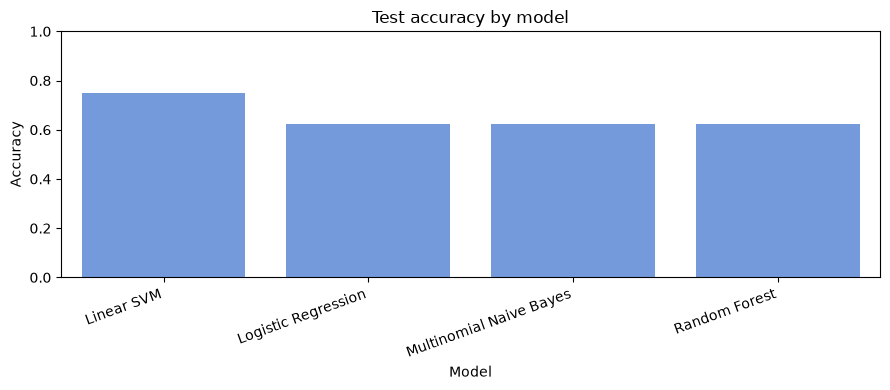

Comment: This chart compares only eight test examples; it is a small, noisy estimate.
Classification report for the CV-selected model:
                        precision    recall  f1-score   support

              DESIGNER       0.00      0.00      0.00         2
         DIGITAL-MEDIA       1.00      1.00      1.00         1
INFORMATION-TECHNOLOGY       0.71      1.00      0.83         5

              accuracy                           0.75         8
             macro avg       0.57      0.67      0.61         8
          weighted avg       0.57      0.75      0.65         8



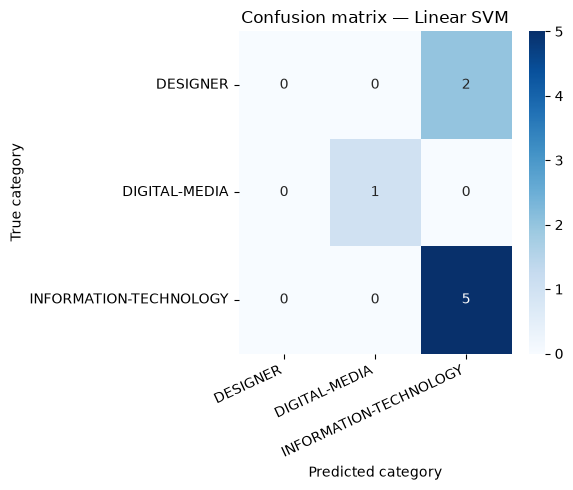

In [ ]:
# Calculate all requested test metrics for each model.
test_rows = []
test_predictions = {}
for name, model in fitted_models.items():
    prediction = model.predict(X_test)
    test_predictions[name] = prediction
    test_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision (weighted)": precision_score(y_test, prediction, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, prediction, average="weighted", zero_division=0),
        "F1 (weighted)": f1_score(y_test, prediction, average="weighted", zero_division=0),
    })
test_table = pd.DataFrame(test_rows).sort_values("F1 (weighted)", ascending=False).reset_index(drop=True)
display(test_table.style.format({col: "{:.3f}" for col in test_table.columns if col != "Model"}))

# Compare each model using test accuracy.
plt.figure(figsize=(9, 4))
sns.barplot(data=test_table, x="Model", y="Accuracy", color="cornflowerblue")
plt.ylim(0, 1)
plt.title("Test accuracy by model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
print("Comment: This chart compares only eight test examples; it is a small, noisy estimate.")

# Select the highest mean CV accuracy model, not the test winner, for tuning.
best_model_name = cv_table.loc[0, "Model"]
best_test_prediction = test_predictions[best_model_name]
print("Classification report for the CV-selected model:")
print(classification_report(y_test, best_test_prediction, labels=np.arange(len(label_encoder.classes_)),
                            target_names=label_encoder.classes_, zero_division=0))
cm = confusion_matrix(y_test, best_test_prediction, labels=np.arange(len(label_encoder.classes_)))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion matrix — {best_model_name}")
plt.xlabel("Predicted category")
plt.ylabel("True category")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Step 12 — Tune the selected model

We use a small grid and four-fold stratified cross-validation. The search sees only training text. The best pipeline is kept together so its TF-IDF vocabulary and model always stay aligned.

In [ ]:
# Small parameter grids keep the search reasonable for this tiny dataset.
parameter_grids = {
    "Logistic Regression": {"classifier__C": [0.1, 1.0, 10.0]},
    "Multinomial Naive Bayes": {"classifier__alpha": [0.1, 0.5, 1.0]},
    "Linear SVM": {"classifier__C": [0.1, 1.0, 10.0]},
    "Random Forest": {"classifier__n_estimators": [50, 100], "classifier__max_depth": [None, 10]},
}
search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=1)),
    ("classifier", clone(models[best_model_name])),
])
grid_search = GridSearchCV(search_pipeline, parameter_grids[best_model_name],
                           cv=cv, scoring="accuracy", n_jobs=1, refit=True)
grid_search.fit(X_train_text, y_train)
best_pipeline = grid_search.best_estimator_
best_vectorizer = best_pipeline.named_steps["tfidf"]
best_model = best_pipeline.named_steps["classifier"]
print("Selected model:", best_model_name)
print("Best parameters:", grid_search.best_params_)
print("Best mean CV accuracy:", round(grid_search.best_score_, 3))
print("Tuned model test accuracy:", round(accuracy_score(y_test, best_pipeline.predict(X_test_text)), 3))

Selected model: Linear SVM
Best parameters: {'classifier__C': 1.0}
Best mean CV accuracy: 0.792
Tuned model test accuracy: 0.75


## Step 13 — See useful words for each category

Linear models have coefficients that show which words push a prediction toward a category. If the selected model has coefficients, we use it. Otherwise, we fit a Logistic Regression model for this explanation only.

In [ ]:
# Use coefficients when available; fall back to a linear Logistic Regression explanation.
if hasattr(best_model, "coef_"):
    coefficient_model = best_model
    coefficient_vectorizer = best_vectorizer
else:
    coefficient_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=1)),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    coefficient_pipeline.fit(X_train_text, y_train)
    coefficient_model = coefficient_pipeline.named_steps["classifier"]
    coefficient_vectorizer = coefficient_pipeline.named_steps["tfidf"]

feature_names = coefficient_vectorizer.get_feature_names_out()
for row_index, class_id in enumerate(coefficient_model.classes_):
    weights = coefficient_model.coef_[row_index]
    top_indices = np.argsort(weights)[-10:][::-1]
    print(f"\nTop words for {label_encoder.inverse_transform([class_id])[0]}:")
    display(pd.DataFrame({"word": feature_names[top_indices], "coefficient": weights[top_indices]}))
print("Comment: These words are clues learned from this small sample; they are not a complete skill list.")


Top words for DESIGNER:


,word,coefficient
0,patient,0.497256
1,design,0.468736
2,designer,0.438354
3,floral,0.423756
4,product,0.338780
5,construction,0.322633
6,nursing,0.310058
7,floral designer,0.302683
8,garment,0.284294
9,mechanical,0.280397



Top words for DIGITAL-MEDIA:


,word,coefficient
0,ad,0.582790
1,campaign,0.538488
2,advertising,0.501936
3,medium,0.352680
4,esxi,0.309245
5,sale,0.303077
6,lafayette,0.273311
7,radio,0.267813
8,recruitment,0.261355
9,public relation,0.256515



Top words for INFORMATION-TECHNOLOGY:


,word,coefficient
0,technology,0.517253
1,information,0.513384
2,system,0.493345
3,information technology,0.448330
4,letter,0.407914
5,network,0.349626
6,software,0.303494
7,project,0.294070
8,application,0.285757
9,management,0.284738


Comment: These words are clues learned from this small sample; they are not a complete skill list.


## Step 14 — Predict a new resume

This function cleans the new text, uses the tuned TF-IDF vectorizer and model, and returns a category plus a score for every category. The scores are model probabilities when available; otherwise they are normalized decision scores and should be read only as relative confidence.

In [ ]:
def predict_category(resume_text):
    # Apply the same cleaning and feature conversion used during training.
    cleaned_text = clean_resume(resume_text)
    features = best_vectorizer.transform([cleaned_text])
    predicted_id = int(best_model.predict(features)[0])

    # Some classifiers have probabilities; Linear SVM has decision scores instead.
    if hasattr(best_model, "predict_proba"):
        scores = best_model.predict_proba(features)[0]
        score_kind = "probability"
    else:
        decision = np.asarray(best_model.decision_function(features)).reshape(-1)
        decision = decision - decision.max()
        exp_scores = np.exp(decision)
        scores = exp_scores / exp_scores.sum()
        score_kind = "normalized decision score"

    per_category = {label_encoder.inverse_transform([int(class_id)])[0]: float(score)
                    for class_id, score in zip(best_model.classes_, scores)}
    return {
        "predicted_category": label_encoder.inverse_transform([predicted_id])[0],
        "scores": per_category,
        "score_kind": score_kind,
    }

# Three fictional examples show the intended kinds of input.
sample_resumes = {
    "IT sample": "python developer with experience in sql cloud computing machine learning data analysis and software testing",
    "Designer sample": "graphic designer skilled in typography branding illustration adobe photoshop visual design and user experience",
    "Digital media sample": "digital media specialist creating social media campaigns video content photography analytics and audience engagement",
}
for sample_name, sample_text in sample_resumes.items():
    print(sample_name, "=>", predict_category(sample_text))

IT sample => {'predicted_category': 'INFORMATION-TECHNOLOGY', 'scores': {'DESIGNER': 0.24853763332450615, 'DIGITAL-MEDIA': 0.255436957051906, 'INFORMATION-TECHNOLOGY': 0.4960254096235877}, 'score_kind': 'normalized decision score'}
Designer sample => {'predicted_category': 'INFORMATION-TECHNOLOGY', 'scores': {'DESIGNER': 0.36951274580719906, 'DIGITAL-MEDIA': 0.2411976322550471, 'INFORMATION-TECHNOLOGY': 0.3892896219377539}, 'score_kind': 'normalized decision score'}
Digital media sample => {'predicted_category': 'DIGITAL-MEDIA', 'scores': {'DESIGNER': 0.2212034899906692, 'DIGITAL-MEDIA': 0.4905382390038145, 'INFORMATION-TECHNOLOGY': 0.2882582710055164}, 'score_kind': 'normalized decision score'}


## Step 15 — Match a resume to sample jobs

Cosine similarity compares TF-IDF vectors. The percentage is a text similarity score, not the chance of getting hired. The five job examples are small demonstrations. The skill-gap function checks a short, editable skills list for each job.

In [ ]:
# Five fictional job descriptions cover the three dataset categories.
sample_jobs = [
    {"title": "Junior Data Scientist", "category": "INFORMATION-TECHNOLOGY", "description": "python machine learning deep learning tensorflow sql pandas numpy scikit learn docker git aws statistics data visualization cloud computing"},
    {"title": "Cloud Support Intern", "category": "INFORMATION-TECHNOLOGY", "description": "cloud computing aws azure linux networking python sql troubleshooting git security"},
    {"title": "Graphic Design Intern", "category": "DESIGNER", "description": "graphic design branding typography adobe illustrator photoshop layout visual communication"},
    {"title": "UI UX Design Assistant", "category": "DESIGNER", "description": "user experience ui ux prototyping figma wireframes visual design research accessibility"},
    {"title": "Digital Media Coordinator", "category": "DIGITAL-MEDIA", "description": "digital media social media content creation video editing photography analytics campaign management audience engagement"},
]
job_df = pd.DataFrame(sample_jobs)

def match_jobs(resume_text, jobs=job_df, top_n=3):
    # Fit TF-IDF on the resume and job descriptions together for a shared vocabulary.
    cleaned_resume = clean_resume(resume_text)
    cleaned_jobs = [clean_resume(description) for description in jobs["description"]]
    matching_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
    matrix = matching_vectorizer.fit_transform([cleaned_resume] + cleaned_jobs)
    similarities = cosine_similarity(matrix[0:1], matrix[1:]).flatten()
    result = jobs[["title", "category"]].copy()
    result["match_percent"] = (similarities * 100).round(1)
    return result.sort_values("match_percent", ascending=False).head(top_n).reset_index(drop=True)

# Import the cosine similarity helper used above.
from sklearn.metrics.pairwise import cosine_similarity

print("Top 3 jobs for the IT sample:")
display(match_jobs(sample_resumes["IT sample"]))

job_skill_lists = {
    "Junior Data Scientist": ["python", "machine learning", "deep learning", "tensorflow", "sql", "pandas", "numpy", "statistics", "data visualization", "cloud computing"],
    "Cloud Support Intern": ["cloud computing", "aws", "azure", "linux", "networking", "python", "sql", "git", "security"],
    "Graphic Design Intern": ["graphic design", "branding", "typography", "illustrator", "photoshop", "layout"],
    "UI UX Design Assistant": ["user experience", "figma", "prototyping", "wireframes", "research", "accessibility"],
    "Digital Media Coordinator": ["social media", "content creation", "video editing", "photography", "analytics", "campaign management"],
}

def find_skill_gaps(resume_text, job_title):
    # Return listed job skills that do not appear in the cleaned resume text.
    resume_words = set(clean_resume(resume_text).split())
    missing = []
    for skill in job_skill_lists[job_title]:
        skill_words = clean_resume(skill).split()
        if not all(word in resume_words for word in skill_words):
            missing.append(skill)
    return missing

print("Skills to consider for the Junior Data Scientist job:")
print(find_skill_gaps(sample_resumes["IT sample"], "Junior Data Scientist"))

Top 3 jobs for the IT sample:


,title,category,match_percent
0,Junior Data Scientist,INFORMATION-TECHNOLOGY,23.0
1,Cloud Support Intern,INFORMATION-TECHNOLOGY,13.1
2,UI UX Design Assistant,DESIGNER,3.5


Skills to consider for the Junior Data Scientist job:
['deep learning', 'tensorflow', 'pandas', 'numpy', 'statistics', 'data visualization']


## Step 16 — Save and reload the model

The tuned vectorizer, label encoder, and classifier are saved as separate files. A new app or script can load them and transform new resume text with the same vocabulary.

In [ ]:
# Save model parts in a local folder so they can be reused by a small API later.
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)
joblib.dump(best_vectorizer, artifact_dir / "resume_tfidf_vectorizer.joblib")
joblib.dump(label_encoder, artifact_dir / "resume_label_encoder.joblib")
joblib.dump(best_model, artifact_dir / "resume_category_model.joblib")
print("Saved files:", sorted(path.name for path in artifact_dir.glob("*.joblib")))

# Example: load the three files again and make one prediction.
loaded_vectorizer = joblib.load(artifact_dir / "resume_tfidf_vectorizer.joblib")
loaded_label_encoder = joblib.load(artifact_dir / "resume_label_encoder.joblib")
loaded_model = joblib.load(artifact_dir / "resume_category_model.joblib")
loaded_features = loaded_vectorizer.transform([clean_resume(sample_resumes["IT sample"])])
loaded_category = loaded_label_encoder.inverse_transform(loaded_model.predict(loaded_features))
print("Loaded model prediction:", loaded_category[0])

Saved files: ['resume_category_model.joblib', 'resume_label_encoder.joblib', 'resume_tfidf_vectorizer.joblib']


Loaded model prediction: INFORMATION-TECHNOLOGY


## Step 17 — Limitations and conclusion

This dataset has only **32 resumes**: 19 Information Technology, 7 Designer, and 6 Digital Media. The test set has only eight examples. Scores can therefore be unstable, and a high score can happen by chance. The notebook prints the measured values above; they should not be treated as reliable production accuracy.

A larger dataset, such as the Kaggle Resume Dataset often described as having 2,484 resumes and 24 categories, would give a stronger evaluation after its license and category mapping are checked. Future work includes collecting consented student resumes and labeled jobs, testing on a separate larger dataset, using OpenAI embeddings for richer semantic matching, and connecting the model to the Flutter app through a Flask or FastAPI REST API.